
esm-piControl
co3os files        : 25
co3sataragos files : 25
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/co3os/gr/latest/co3os_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/co3os/gr/latest/co3os_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/co3sataragos/gr/latest/co3sataragos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/co3sataragos/gr/latest/co3sataragos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
co3os files        : 23
co3sataragos files : 23
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/co3os_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/co3os_Omon_NorESM2-LM_esm-up2

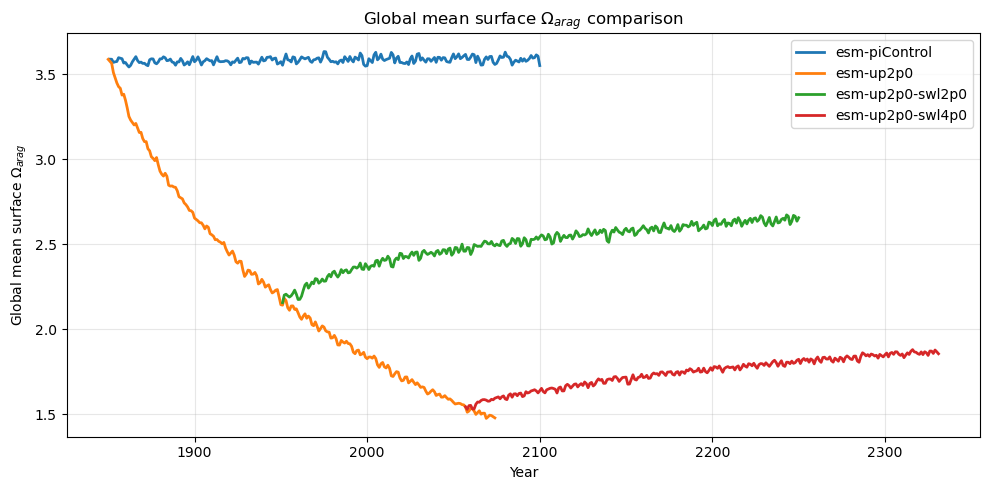

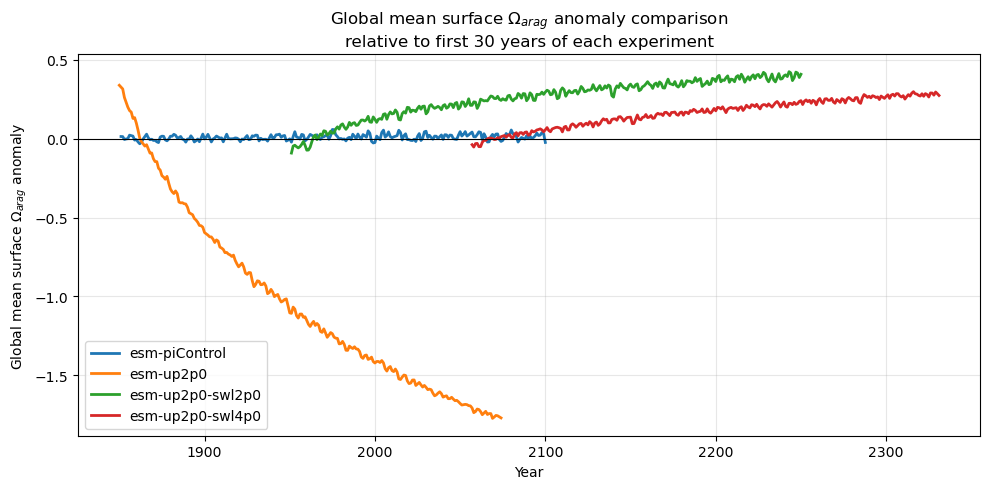

In [2]:
import xarray as xr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon",
        "co3_pattern": "co3os/gr/latest/co3os_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
        "co3sat_pattern": "co3sataragos/gr/latest/co3sataragos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010",
        "co3_pattern": "co3os_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
        "co3sat_pattern": "co3sataragos_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009",
        "co3_pattern": "co3os_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
        "co3sat_pattern": "co3sataragos_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl4p0/v20251010",
        "co3_pattern": "co3os_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
        "co3sat_pattern": "co3sataragos_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
    },
}


# ============================================================
# Function
# ============================================================

def compute_global_mean_omega_arag(exp_path, co3_pattern, co3sat_pattern):
    co3_files = sorted(glob.glob(os.path.join(exp_path, co3_pattern)))
    co3sat_files = sorted(glob.glob(os.path.join(exp_path, co3sat_pattern)))

    print(f"co3os files        : {len(co3_files)}")
    print(f"co3sataragos files : {len(co3sat_files)}")

    if len(co3_files) == 0:
        raise FileNotFoundError(
            f"No co3os files found: {os.path.join(exp_path, co3_pattern)}"
        )

    if len(co3sat_files) == 0:
        raise FileNotFoundError(
            f"No co3sataragos files found: {os.path.join(exp_path, co3sat_pattern)}"
        )

    print(co3_files[0])
    print(co3_files[-1])
    print(co3sat_files[0])
    print(co3sat_files[-1])

    ds_co3 = xr.open_mfdataset(
        co3_files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": -1},
    )

    ds_sat = xr.open_mfdataset(
        co3sat_files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": -1},
    )

    co3 = ds_co3["co3os"]
    co3sat = ds_sat["co3sataragos"]

    omega_arag = co3 / co3sat
    omega_arag.name = "omega_arag"
    omega_arag.attrs["long_name"] = "Surface aragonite saturation state"
    omega_arag.attrs["units"] = "1"

    weights = np.cos(np.deg2rad(ds_co3["latitude"]))

    weights = weights.where(
        np.isfinite(omega_arag.isel(time=0)),
        0.0
    ).fillna(0.0)

    omega_global = (
        omega_arag
        .weighted(weights)
        .mean(dim=["j", "i"], skipna=True)
        .compute()
    )

    omega_global.name = "global_mean_omega_arag"

    omega_ann = omega_global.groupby("time.year").mean("time")
    omega_ann.name = "global_mean_omega_arag_annual"

    ds_co3.close()
    ds_sat.close()

    return omega_ann


# ============================================================
# Load all experiments
# ============================================================

omega_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    omega_ann_dict[exp] = compute_global_mean_omega_arag(
        exp_path=info["path"],
        co3_pattern=info["co3_pattern"],
        co3sat_pattern=info["co3sat_pattern"],
    )


# ============================================================
# Plot absolute OmegaArag
# ============================================================

plt.figure(figsize=(10, 5))

for exp, omega_ann in omega_ann_dict.items():
    plt.plot(
        omega_ann["year"],
        omega_ann,
        lw=2,
        label=exp,
    )

plt.xlabel("Year")
plt.ylabel(r"Global mean surface $\Omega_{arag}$")
plt.title(r"Global mean surface $\Omega_{arag}$ comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot anomalies relative to each experiment's first 30 years
# ============================================================

plt.figure(figsize=(10, 5))

for exp, omega_ann in omega_ann_dict.items():
    years = omega_ann["year"].values
    ref_years = years[:30]

    omega_ref = omega_ann.sel(year=ref_years).mean("year")
    omega_anom = omega_ann - omega_ref

    plt.plot(
        omega_ann["year"],
        omega_anom,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel(r"Global mean surface $\Omega_{arag}$ anomaly")
plt.title(
    r"Global mean surface $\Omega_{arag}$ anomaly comparison" "\n"
    "relative to first 30 years of each experiment"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


esm-piControl
co3os files        : 25
co3sataragos files : 25
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/co3os/gr/latest/co3os_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/co3os/gr/latest/co3os_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/co3sataragos/gr/latest/co3sataragos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon/co3sataragos/gr/latest/co3sataragos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
co3os files        : 23
co3sataragos files : 23
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/co3os_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/co3os_Omon_NorESM2-LM_esm-up2

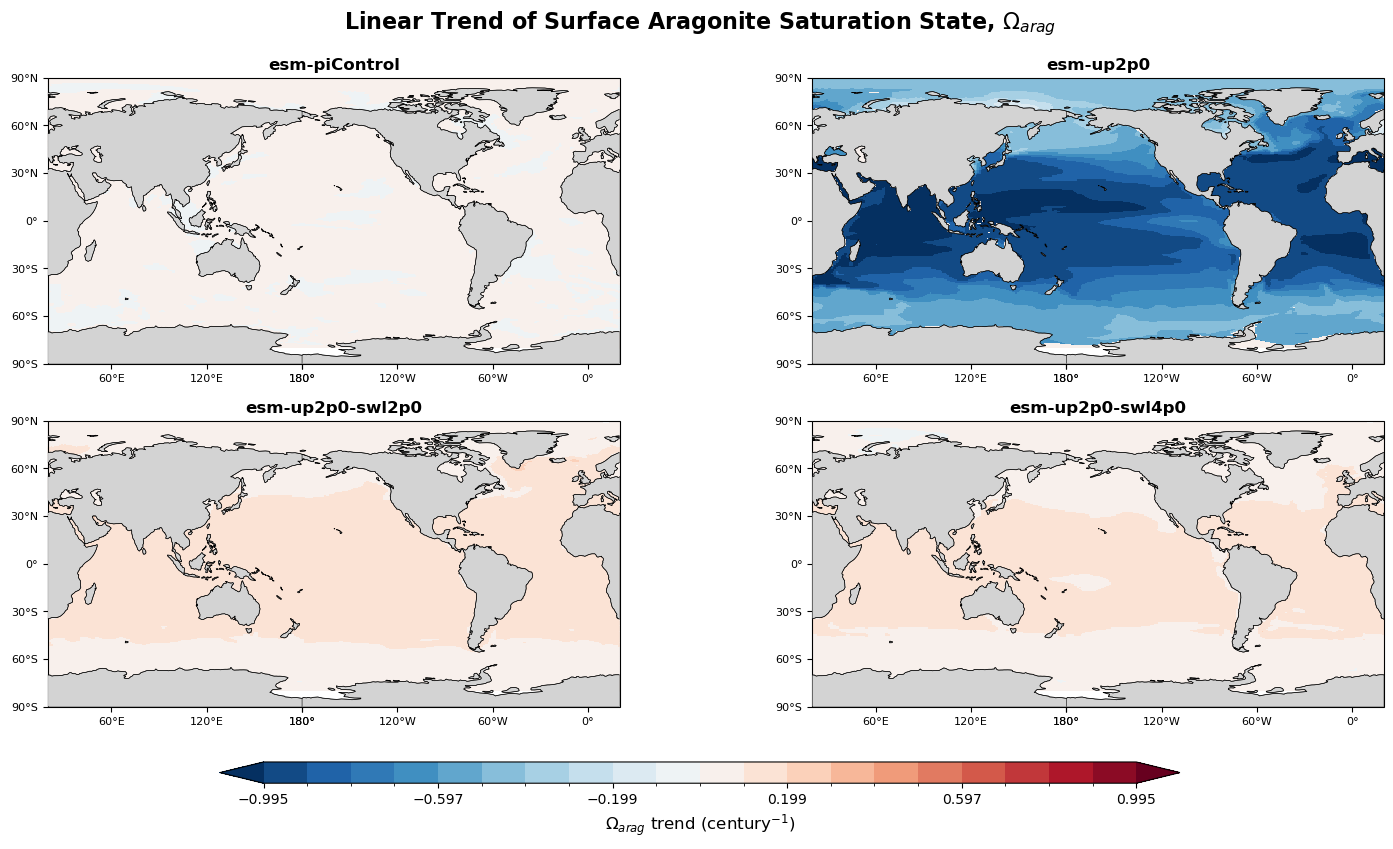

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import glob
import os
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="The colormap's 'bad' has been set")

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/esm-piControl/r1i1p1f1/Omon",
        "co3_pattern": "co3os/gr/latest/co3os_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
        "co3sat_pattern": "co3sataragos/gr/latest/co3sataragos_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010",
        "co3_pattern": "co3os_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
        "co3sat_pattern": "co3sataragos_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl2p0/v20251009",
        "co3_pattern": "co3os_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
        "co3sat_pattern": "co3sataragos_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0-swl4p0/v20251010",
        "co3_pattern": "co3os_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
        "co3sat_pattern": "co3sataragos_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
    },
}


# ============================================================
# Function
# ============================================================

def compute_omega_arag_trend_map(exp_path, co3_pattern, co3sat_pattern):
    co3_files = sorted(glob.glob(os.path.join(exp_path, co3_pattern)))
    co3sat_files = sorted(glob.glob(os.path.join(exp_path, co3sat_pattern)))

    print(f"co3os files        : {len(co3_files)}")
    print(f"co3sataragos files : {len(co3sat_files)}")

    if len(co3_files) == 0:
        raise FileNotFoundError(f"No co3os files found: {os.path.join(exp_path, co3_pattern)}")

    if len(co3sat_files) == 0:
        raise FileNotFoundError(f"No co3sataragos files found: {os.path.join(exp_path, co3sat_pattern)}")

    print(co3_files[0])
    print(co3_files[-1])
    print(co3sat_files[0])
    print(co3sat_files[-1])

    ds_co3 = xr.open_mfdataset(
        co3_files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": 120},
    )

    ds_sat = xr.open_mfdataset(
        co3sat_files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": 120},
    )

    co3 = ds_co3["co3os"]
    co3sat = ds_sat["co3sataragos"]

    omega = co3 / co3sat
    omega.name = "omega_arag"
    omega.attrs["units"] = "1"

    omega_ann = omega.groupby("time.year").mean("time")

    year = omega_ann["year"]
    x = year - year.mean()

    # Trend: Omega_arag per century
    trend = (
        (omega_ann * x).sum("year", skipna=True)
        / (x ** 2).sum("year", skipna=True)
    ) * 100.0

    trend.name = "omega_arag_trend"
    trend.attrs["units"] = "century-1"

    trend = trend.assign_coords(
        longitude=ds_co3["longitude"],
        latitude=ds_co3["latitude"],
    )

    trend = trend.compute()

    ds_co3.close()
    ds_sat.close()

    return trend


# ============================================================
# Compute trend maps
# ============================================================

trend_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    trend_dict[exp] = compute_omega_arag_trend_map(
        exp_path=info["path"],
        co3_pattern=info["co3_pattern"],
        co3sat_pattern=info["co3sat_pattern"],
    )


# ============================================================
# Plot 2 x 2 panel
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 8.5),
    subplot_kw={"projection": map_crs},
)

axes = axes.flatten()

# Color range based only on esm-up2p0, covering about 90%
ref_trend = trend_dict["esm-up2p0"]

ref_values = ref_trend.values
ref_values = ref_values[np.isfinite(ref_values)]

vmax = np.nanpercentile(np.abs(ref_values), 90)
vmin = -vmax

levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) + 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="both"
)

# Draw maps
for ax, (exp, trend) in zip(axes, trend_dict.items()):

    pcm = ax.pcolormesh(
        trend["longitude"],
        trend["latitude"],
        trend,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11,
    )

    ax.set_global()

    ax.set_xticks(np.arange(-180, 181, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(
        exp,
        fontsize=12,
        fontweight="bold",
    )

# Layout and colorbar outside
fig.subplots_adjust(
    left=0.05,
    right=0.97,
    top=0.90,
    bottom=0.16,
    wspace=0.08,
    hspace=0.20,
)

cbar_ax = fig.add_axes([0.20, 0.07, 0.60, 0.025])

cbar = fig.colorbar(
    pcm,
    cax=cbar_ax,
    orientation="horizontal",
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    extend="both",
)

cbar.set_label(
    r"$\Omega_{arag}$ trend (century$^{-1}$)",
    fontsize=12,
)

fig.suptitle(
    r"Linear Trend of Surface Aragonite Saturation State, $\Omega_{arag}$",
    fontsize=16,
    fontweight="bold",
)

plt.show()